# INSERT TITLE HERE (change later)

Pistol rounds get treated as disproportionately important in pro play — teams draft specific strategies around them, and often, analysts and casters talk about "stealing momentum," describing the mental battle between teams, and how winning (or similarly, losing) a clutch round, or ending a round win-streak can affect the mental and energy of the opposing team. 

A recurring event that is often associated with momentum in professional play is winning the second round, after winning the first/pistol round; this is also known as the "anti-eco" round. The anti-eco round is when the team who won the pistol round buys stronger weapons, armor and abilities to overpower their opponents, who have less money and are only able to buy weaker weapons and limited abilities; thus pushing their financial advantage. 

Qualitatively, the advantages of winning the anti-eco round are clear: the team is two rounds closer to winning the entire match, and the mental boost from winning two rounds in a row would boost team morale. From an in-game financial perspective; if there are many players who survive after winning the anti-eco round, the team can use their weapons which they bought in the anti-eco round in the next round; this is called the "bonus" or "boost" round, however this event won't be explored in this project. 

Before we continue, one absolute fact should be made clear: as thoroughly as we can dissect the advantages and positive impacts that winning the anti-eco brings, **like any sport, or any videogame, previous rounds, sets, or rallies do not inherently determine what happens next.**

# AIM (add something here, summary of the aim)

Thus, does winning the pistol round actually tell us anything about winning the round after it — or is "momentum" just a story casters tell? We'll start from the most basic test of this hypothesis, and further refine the test, as assumptions begin to break. 

It should be stated that analysing rounds from a purely statistical perspective is incredibly difficult. There are innumerable factors that go into just one play within a round, let alone 20 rounds in a single match, many of which are inherently unquantifiable, such as team synergy, midrounding, or even the crux of the project: momentum. 

# DATA COLLECTION 

Data is all sourced from vlrdevapi, a Python scraper which collects data from the VLR.gg forum. The code to scrape the data used is below.

In [1]:
# CODE WORKS AS OF JULY 2026 - will update to current vers of vlrdevapi soon.

import vlrdevapi as vlr
import json
from dataclasses import asdict

# insert team-specific VLR ID 
team_id = 2593

team = vlr.team.info(team_id=team_id)
completed = vlr.team.completed_matches(team_id=team_id, limit = 12)

# compile a list of matches
matches_data = []
for match in completed:
    if not match.match_id:
        continue

    # compile a list of maps 
    maps = vlr.series.matches(series_id=match.match_id)
    maps_data = []
    for map_data in maps:
        rounds_data = [asdict(r) for r in map_data.rounds] if map_data.rounds else []
        maps_data.append({
            "map_name": map_data.map_name,
            "rounds": rounds_data,
        })

    matches_data.append({
        "match_id": match.match_id,
        "team1": match.team1.name,
        "team2": match.team2.name,
        "maps": maps_data,
    })

output = {
    "team_id": team_id,
    "team_name": team.name,
    "team_tag": team.tag,
    "country": team.country,
    "matches": matches_data,
}

with open("**JSON FILE**", "w", encoding="utf-8") as f:
    json.dump(output, f, indent=2, ensure_ascii=False)

TypeError: got an unexpected keyword argument 'limit'

# Data Format

The scraped data contains information about the team scraped for in "team_id", (which was Fnatic) and the last 20 matches that they have played (from 30th July 2026), formatted into a JSON file. 
The JSON file contains per-round data, including the scoreline at that particular round, the side which won (Attacker or Defender), as well as metadata about the opposing team (e.g. their VLR ID, and team name). A small snippet of what the resulting JSON file looks like is below.

{
  "team_id": 2593,
  "team_name": "FNATIC",
  "team_tag": "FNC",
  "country": "Europe",
  "matches": [
    {
      "match_id": 712819,
      "team1": "FNATIC",
      "team2": "Team Liquid",
      "maps": [
        {
          "map_name": "All",
          "rounds": []
        },
        {
          "map_name": "Summit",
          "rounds": [
            {
              "number": 1,
              "winner_side": "Attacker",
              "method": "Elimination",
              "score": [
                1,
                0
              ],
              "winner_team_id": 474,
              "winner_team_short": "TL",
              "winner_team_name": "Team Liquid"
            },

# Data Limitations

The limitations mainly lie in what data is available for me to scrape from vlrdevapi. For example, even though round economy data is available to view on the VLR forum, scraping this data was unsupported on vlrdevapi. Thus, the resulting statistical model does not take into account how much money was invested into the anti-eco round from the pistol-winning team.

The model that follows these data limitations is thus built around the data that is actually scrapeable, not the data that would be ideal in order to answer the question. 

# METHOD (change title later)

Representing the anti-eco victory is simply a conditional probability (see below).
$$P(\text{win round 2} \mid \text{won round 1})$$
However, should this conditional probability be represented using a point estimate, or a probability distribution? 

A point estimate would be straight-to-the-point: this team has x chance to win the anti-eco.  $$\hat{p} = \frac{\#\{\text{round 1 won} \cap \text{round 2 won}\}}{\#\{\text{round 1 won}\}}$$
This ratio is the **Maximum Likelihood Estimator** for p, the probability of winning the anti-eco. Each individual anti-eco outcome follows a Bernoulli distribution - a random variable taking value 1 (a win with probability p) and 0 (a loss with probability 1-p), which in theory, fits our scenario as a team can either win or lose the anti-eco.

However, the problem with using a point estimate, and using the Bernoulli distribution in this way is that, in-game, to win a round (e.g. eliminating the enemy team; defusing or exploding the spike) is inherently uncertain. Unlike the binary outcome, the steps leading up to the outcome are inherently uncertain; **no one can predict how a gunfight will go before it actually happens**. A point estimate would omit these inherent uncertainties, thus reducing the reliability of the model. 

Instead, if we use a probability distribution, we are able to graphically quantify the data's uncertainty, and it allows us to distinguish between any uncertainty, whether it is epistemic, (uncertainty due to a lack of information, an important point which will be further explained later on) or aleatory (inherently uncertain, e.g. the gunfight example).

So which probability distribution would best fit the scenario? 

This decision requires taking two key details into account, the scenario and the data we are given about the scenario. By transforming the JSON file into a dataframe, we can cleanly visualise the data and explore it in greater detail.

In [3]:
import pandas as pd
from src.pipeline.pandasfile import load_rounds_dataframe

df = load_rounds_dataframe("src/data/raw/rounds_raw.json") 
df.head()

,match_id,map_name,number,winner_side,method,score,winner_team_id,winner_team_short,winner_team_name,won_by_queried_team,fnc_side
0,712819,Summit,1,Attacker,Elimination,"[1, 0]",474,TL,Team Liquid,False,Defender
1,712819,Summit,2,Attacker,Elimination,"[2, 0]",474,TL,Team Liquid,False,Defender
2,712819,Summit,3,Attacker,Elimination,"[3, 0]",474,TL,Team Liquid,False,Defender
3,712819,Summit,4,Attacker,Elimination,"[4, 0]",474,TL,Team Liquid,False,Defender
4,712819,Summit,5,Attacker,SpikeExplosion,"[5, 0]",474,TL,Team Liquid,False,Defender


A binomial distribution seems fitting for the scenario, especially considering that winning the anti-eco is fundamentally a count. So why not model the scenario as Binomial(n,p)?

<img src="attachment:ae1cf5b7-1d1b-404f-8231-2f0b81f55f93.png" width="40%">


Firstly, a key rule to use a binomial distribution to model data is that the chances of success must be fixed across all trials. This is definitely not the case when it comes to winning rounds in Valorant. As previously stated, **previous rounds do not inherently determine what happens next round.** However, there's an even more impactful underlying problem with using a binomial distribution here.

The main problem with this approach is that it does not properly resolve the underlying uncertainty issue which using a point estimate would have. To use the binomial distribution at all, we need to have a value for p, and the only value we have is the MLE estimate from before. Using this as our value of p would correctly describe the count of anti-eco wins, but addresses nothing about the confidence of p itself. So although we have swapped a point estimate for a probability distribution, the parameter powering the distribution is still an unconfident, fixed value, acquired from the same naïve method as before. Using the binomial distribution in this way is simply the same as using our point estimate, just with extra steps. 

To give an example, let's look at the dataframe above. Say that we used our MLE formula to quantify p, e.g. p = 0.8. If we naively believe this value, then we can say that Fnatic converts 80% of pistol round wins to anti-eco victories. However, this calculation carries no information about how much data it's built on, e.g. how big is the dataset where this data has been derived from. If the dataset only took into account 5 games, and then in those 5 games, 80% of pistol round wins were converted into anti-eco wins, then we have naively believed that 80% of pistol rounds wins can be converted into anti-ecos, even if a team were to play 100 matches. The MLE has no way to distinguish that scenario than from one built on far more data.

Simply put, the binomial distribution would answer "given p, how many anti-ecos should i expect to win?" and not "given the data, what should p actually be?" Although the former question is effectively the thesis of the project, the answer it produces would carry no weight in how confident we should be in it; it is just counting the number of round1->round2 wins against the total round1->round 2 sets played.

However, this does not mean that we have discarded using a Binomial distribution entirely, in fact, it forms a core part of the maths we will use later on down the line.

For now though, we have sidelined using a discrete probability distribution as our main output. This leaves us with continuous probability distributions as our next candidate.

A continuous probability distribution resolves our issues regarding counting; by representing our confidence in p using a smooth, continuous curve, we are displaying that nearby values of p are assigned similarly plausible density, rather than having to jump between disconnected columns of potential (approximate) buckets of p-values.

<img src="attachment:a5f517e3-f498-44ae-b0bc-5f580fe017a8.png" width="30%">

Looking at the most famous continuous distribution, the Normal distribution, there is one key characteristic of this distribution that prevents us from using it in this project. The Normal distribution supports values from -infinity to +infinity, and assigns non-zero values both below 0 and above 1. However, p is a probability, and probabilities are bounded from [0,1]. Thus, the output also needs to be bounded in this way too. 

Another issue with using the Normal distribution is that it is inflexible. By definition, the skewness of a normal distribution is zero, and the probability of extreme values on each tail is identical. This is inherently incompatible with the scenario, as the likelihoods of winning Valorant rounds can vary widely across different teams, and different maps. Some teams may convert many anti-eco rounds (thus their p-value would be close to 1), and others may convert very few (their p-value would be close to 0). Thus, our resulting distribution needs to handle skewness and points close to the extrema well. 

So the three core conditions of our chosen probability distribution are that:
- It is naturally bounded at [0,1].
- Can handle skewed data well.
- Handles values close to extrema well. 

Naturally, this leads us to the Beta Distribution. The distribution is controlled by two shape parameters: α (alpha) and β (beta). These two parameters allow the distribution to take on a curve that is concentrated at any point between 0 and 1, whether that be skewed, concentrated at extrema or flat across the entire interval, depending on their values. 

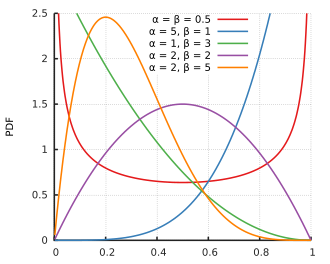

The purpose of the Beta distribution here is not to directly model round outcomes. Its purpose is to model the uncertainty regarding p, the "true" anti-eco conversion rate. Even before looking at any data, modelling the scenario as Beta(α,β) allows us to express a starting belief (AKA a prior) as to what p is likely to be, and our confidence in that belief. Informally, the purpose of a Beta distribution is to model "probabilities of probabilities."

<img src="attachment:05a86af6-baac-4392-9ac9-25fc23cbbc85.png" width="40%"> 

This is where we re-introduce the Binomial distribution. Instead of having it directly power p as a fixed and unconfident value, it now displays the likelihood that we will observe the actual anti-eco win/loss counts in our data. Pairing a Beta prior over p with a Binomial likelihood over the observed counts is what lets us update our belief about p once we've seen real data, turning a starting guess into an updated, more confident belief (AKA a posterior) that's actually grounded in what we observed.

The combination of both the Beta and Binomial distributions is called the Beta-Binomial model. The Beta distribution is the conjugate prior - **the prior and posterior distribution will both be Beta distributions.** The Binomial distribution acts as a likelihood function, effectively: **"if p was the true probability of anti-eco conversions, how probable would it be to observe x anti-eco victories out of n round1 -> round2 sets?"** 

Mathematically speaking, given that **p~Beta(α,β)** is our prior, uncertain belief with density **f(p)**, we update our belief using a Binomial likelihood function, where our observations are modelled as: **X | p∼Binomial(n,p)**. Our resulting posterior density comes as a result of Bayes' rule combining both distributions as: 

$$
f(p \mid X=x) = \frac{P(X=x \mid p)f(p)}{P(X=x)} \propto P(X=x \mid p)f(p)
$$

where **P(X=x)** is the marginal likelihood. Computing it directly usually requires numerical methods, but because the Beta and Binomial are conjugate, the posterior distribution is represented in a closed form, not approximated. 

Thus, P(win round 2 | won round 1) is no longer a single number, it is a full distribution, supported with data, over potential values of p.

$$ 
p \mid X=x \sim \mathrm{Beta}(\alpha+x,\beta+n-x)
$$

We have now established our way of quantifying the probability that a team converts a pistol into an anti-eco win. Now we need to explore the pipeline further downstream, from parsing our data into a dataframe, to then passing that dataframe into the mathematical pipeline which will eventually produce our desired results. 

Firstly, what needs to be done is to convert the JSON data into a dataframe. 

In [1]:
from src.pipeline.pandasfile import fnc_side

def load_rounds_dataframe_example(json_path="rounds_raw.json"):

    """
    Load round details from a JSON file and return them as a flattened Pandas DataFrame.

    Parameters:
        json_path (str): Path to the input JSON file.

    Returns:
        pd.DataFrame: DataFrame containing parsed round data.
    """

    # Load and parse the raw JSON file
    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    # Extract team identifiers to use for comparisons
    team_tag = data["team_tag"]
    team_id = data["team_id"]
    rows = []

    # Iterate through nested hierarchy: matches -> maps -> rounds
    for match in data["matches"]:
        for map_data in match["maps"]:
            for r in map_data["rounds"]:

                # Construct base row dictionary with match, map, and round data
                row = {
                    "match_id": match["match_id"],
                    "map_name": map_data["map_name"],
                    **r,  # Merge round details (number, winner_team_short, method, score, etc.)
                }

                # Check if FNC won 
                row["won_by_queried_team"] = (
                    r.get("winner_team_short") == team_tag
                )
                row["fnc_side"] = fnc_side(
                    r, team_id
                )  # Determine side (ATK/DEF) for the target team

                rows.append(row)

    # Convert the list of parsed dictionaries into a DataFrame
    return pd.DataFrame(rows)

displayed_df = load_rounds_dataframe_example("src/data/raw/rounds_raw.json")
displayed_df

NameError: name 'json' is not defined

You may have noticed that at the top of the cell, a function "fnc_side()" is imported and is called within the function. This function is displayed and explained below.

In [5]:
def fnc_side_example(round_, fnc_team_id):

    """
    Determines which side FNC were playing during the round

    Parameters:
        round_: isolated round row in match dataframe
        fnc_team_id: vlr-specific id for Fnatic

    Returns:
        str: "Attacker" or "Defender
    """

    if round_["winner_team_id"] == fnc_team_id:
        return round_["winner_side"]
    else:
        return "Defender" if round_["winner_side"] == "Attacker" else "Attacker"

We now have the dataframe ready to be passed further into the pipeline. However, the dataframe produced by the function contains data that is not relevant to the analysis. The current dataframe outputs every round in a match as a row, when we only want the pistol rounds and anti-ecos that happened in every match. To resolve this, two pivot tables of the dataframe are created, which remove the unnecessary details from the dataframe. 

In [6]:
def _pistol_round2_subset(rounds_df, pistol_round):

    """
    Reshapes rounds_df (rows = individual rounds) into one row per
    (match_id, map_name) with a won_pistol / won_round2 / fnc_side triple
    for the given pistol_round. Returns None if this pistol_round doesn't
    appear in the data (e.g. no overtime rounds for round 13).
    """

    round2 = pistol_round + 1

    # rows = (match_id, map_name), columns = round number, values = won_by_queried_team
    pivot = rounds_df.pivot_table(
        index=["match_id", "map_name"],
        columns="number",
        values="won_by_queried_team",

        # aggfunc is redundant as all rows are independent and unique; func needs arg to be passed
        aggfunc="first",
    )

    # same reshape, but tracking which side FNC was on for each round number
    side_pivot = rounds_df.pivot_table(
        index=["match_id", "map_name"],
        columns="number",
        values="fnc_side",

        # same as above 
        aggfunc="first",
    )

    if pistol_round not in pivot.columns or round2 not in pivot.columns:
        return None

    # get only pistol round and 2nd round rows
    subset = pivot[[pistol_round, round2]].dropna()
    subset = subset.astype(bool)

    # categorise each element in each row by col
    subset = subset.rename(columns={pistol_round: "won_pistol", round2: "won_round2"})

    # attach the side FNC played on during the pistol round itself 
    subset["fnc_side"] = side_pivot[pistol_round]
    subset = subset.dropna(subset=["fnc_side"])

    return subset.reset_index()


df = load_rounds_dataframe("src/data/raw/rounds_raw.json") 
# pistol_round parameter is set to 1 for demo purposes
# full implementation includes round 13: see GitHub repo for full implementation.
df = _pistol_round2_subset(df, 1) 
df.head(10)

number,match_id,map_name,won_pistol,won_round2,fnc_side
0,594746,Breeze,True,True,Defender
1,594746,Haven,False,False,Attacker
2,594752,Abyss,True,True,Attacker
3,594752,Corrode,True,True,Defender
4,594752,Split,True,False,Attacker
5,594755,Corrode,True,True,Attacker
6,594755,Split,True,True,Attacker
7,594757,Bind,True,True,Attacker
8,594757,Breeze,False,False,Attacker
9,594757,Split,True,True,Defender


The **_summarise()** function below reduces matches to solely those where the queried team won the pistol round. It simply counts the number of pistol rounds won, and then how many of those wins were followed by winning round 2. The conditional probability is then calculated below.

In [7]:
def _summarise(group):
    
    """Turn a subset of rows sharing a conditioning key into one result row."""

    pistol_wins = group[group["won_pistol"] == True]
    if len(pistol_wins) == 0:
        return None

    # sum() to get whole number of victories
    n_win_round2 = pistol_wins["won_round2"].sum()
    n_pistol_wins = len(pistol_wins)
    return {
        "n_pistol_wins": n_pistol_wins,
        "n_win_round2": n_win_round2,

        # p(win round 2 | won round 1) 
        "p_win_round2_given_pistol": n_win_round2 / n_pistol_wins,
    }

# dummmy data — shows what _summarise() does mechanically
dummy_df = pd.DataFrame({
    "won_pistol":  [True, True, True, False],
    "won_round2":  [True, False, True, True],
})

# In the dummy data, there are 3 pistol rounds that were won (the 0th,1st and 2nd pistol rounds), 
# and of those 3 pistol rounds, only 2 resulted in round 2 wins (the 0th and 2nd matches). 
# ∴ conditional probability is 2/3.
_summarise(dummy_df)

{'n_pistol_wins': 3,
 'n_win_round2': np.int64(2),
 'p_win_round2_given_pistol': np.float64(0.6666666666666666)}

In a single match, a pistol win to anti-eco event can happen **exactly twice**: once for defender-side and once for attacker-side, (unless a team is up 12-0 before switching sides, and then wins the pistol round, which in turn wins them the entire game). At half-time, all abilities and acquired money are reset, thus making these events independent. Therefore, analysing both round1 and round13 pistol-anti-eco sets as independent events would provide a more accurate representation of a team's performance. To do this, we can pool the data from each result on a per-side basis. 

In [8]:
def pool_by_side_example(results_df):

    """
    Groups pistol anti-eco sets into attacker-sided or defender-sided.

    Parameters: 
        results_df: raw JSON data transformed into dataframe 

    Outputs: 
        pooled: column called "p_win_round2_given_pistol" as no. of anti-ecos / pistol wins 
    """

    pooled = (
        results_df
        .groupby(["pistol_round", "fnc_side"])[["n_pistol_wins", "n_win_round2"]]
        .sum()
        .reset_index()
    )
    pooled["p_win_round2_given_pistol"] = pooled["n_win_round2"] / pooled["n_pistol_wins"]
    return pooled


# dummy data 
dummy_results = pd.DataFrame({
    "pistol_round":  [1, 1, 1, 1],
    "fnc_side":      ["Attacker", "Attacker", "Defender", "Defender"],
    "n_pistol_wins": [3, 5, 4, 2],
    "n_win_round2":  [2, 4, 1, 2],
})

# Attacker-side: 3+5 = 8 pistol wins. 2+4 = 6 anti-eco wins. ∴ conditional probability is 6/8 or 0.75.
# Defender-side: 4+2 = 6 pistol wins. 1+2 = 3 anti-eco wins. ∴ conditional probability is 3/6 or 0.5. 
pool_by_side_example(dummy_results)

,pistol_round,fnc_side,n_pistol_wins,n_win_round2,p_win_round2_given_pistol
0,1,Attacker,8,6,0.75
1,1,Defender,6,3,0.50


Now, we have outlined all of the conditions which we can analyse the data. However, the results output from each function are still point estimates, summed simply from averaging out observed data. We previously discussed that the results would take on the form of a Beta distribution in order to represent them more accurately. 

In [2]:
from scipy.stats import beta 

def beta_posterior(wins, losses, prior_alpha, prior_beta):

    """
    Beta distribution function. 

    Parameters:
        wins : observed wins from data 
        losses : observed losses from data
        prior_alpha : an estimate/belief of successes (wins)
        prior_beta : an estimate/belief of failures (losses)

    Outputs: 
        updated alpha and beta parameters after observed data (posterior)
        the actual posterior distribution (as scipy beta object) 
    """
    
    alpha_post = prior_alpha + wins
    beta_post = prior_beta + losses

    return alpha_post, beta_post, beta(alpha_post, beta_post)

# dummy data
beta_posterior(10,10,5,5)

(15,
 15,
 <scipy.stats._distn_infrastructure.rv_continuous_frozen at 0x1317c209be0>)

Simply put, the posterior distribution is just addition: real observed wins are added to α and real observed losses are added to β. This works because α and β are considered as **pseudo-observations**, which are simply imagined/estimated wins and losses. Updating the posterior is simply adding the actual wins and losses from the data onto the prior alpha and beta parameters. This is possible as the Beta distribution is the conjugate prior for the Binomial likelihood, or in simpler terms: both share the same algebraic structure, which lets you update your beliefs by just using simple addition.

Now that we have clarified the implementation of our analysis on dummy data, we can now apply these mechanisms to Fnatic's actual pistol-anti-eco round outcomes. The dataframe below aggregates every pistol round FNC played across the 2026 season, pooled by side and conditioned on which round (1 or 13) is being analysed.

In [ ]:
from pistol_round2 import pool_by_side 

def analyze_pistol_conversions(results_df, prior_alpha=None, prior_beta=None, n0=10):
    
    """
    Compute Beta posteriors for pistol-round -> round-2 conversion.

    prior_alpha, prior_beta: optional explicit prior. Must be supplied together.
        If omitted, a shrinkage prior is derived from the pooled global mean
        across all cells, weighted by n0 pseudo-observations.
    n0: pseudo-observation count for the derived shrinkage prior. Ignored if
        prior_alpha/prior_beta are supplied explicitly.

    Returns the result_dataframe enriched with wins, losses, prior_alpha,
    prior_beta, posterior mean, and 95% credible interval bounds/width.
    """

    result_dataframe = pool_by_side(results_df)

    wins = result_dataframe["n_win_round2"]
    losses = result_dataframe["n_pistol_wins"] - wins

    if (prior_alpha is None) != (prior_beta is None):
        raise ValueError("prior_alpha and prior_beta must be supplied together, or not at all.")

    if prior_alpha is None and prior_beta is None:
        total_wins = wins.sum()
        total_trials = (wins + losses).sum()
        global_mean = total_wins / total_trials

        prior_alpha = global_mean * n0
        prior_beta = (1 - global_mean) * n0

    print(wins.dtype, losses.dtype, type(prior_alpha), type(prior_beta))

    alpha_post, beta_post, posterior = beta_posterior(wins, losses, prior_alpha, prior_beta)

    result_dataframe["wins"] = wins
    result_dataframe["losses"] = losses
    result_dataframe["prior_alpha"] = prior_alpha
    result_dataframe["prior_beta"] = prior_beta
    result_dataframe["alpha_post"] = alpha_post
    result_dataframe["beta_post"] = beta_post
    result_dataframe["posterior_mean"] = posterior.mean()
    result_dataframe["ci_lower"] = posterior.ppf(0.025)
    result_dataframe["ci_upper"] = posterior.ppf(0.975)
    result_dataframe["ci_width"] = result_dataframe["ci_upper"] - result_dataframe["ci_lower"]

    return result_dataframe